<a href="https://colab.research.google.com/github/dsaoulis/Thesis/blob/main/LGD_with_ESG_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--------------------------------------------------------------------------------
1. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ EXCEL
--------------------------------------------------------------------------------
✓ Οι σύνδεσμοι και οι δείκτες αρχικοποιήθηκαν επιτυχώς.


--------------------------------------------------------------------------------
2. ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ
--------------------------------------------------------------------------------
Επεξεργασία δείκτη: ATHEX25...
Επεξεργασία δείκτη: STOXX600...
Επεξεργασία δείκτη: S&P500...
Επεξεργασία δείκτη: EUROSTOXX50...

✓ Η επεξεργασία ολοκληρώθηκε επιτυχώς στη μνήμη!


--------------------------------------------------------------------------------
3. ΠΑΡΑΓΩΓΗ ΓΡΑΦΗΜΑΤΩΝ
--------------------------------------------------------------------------------


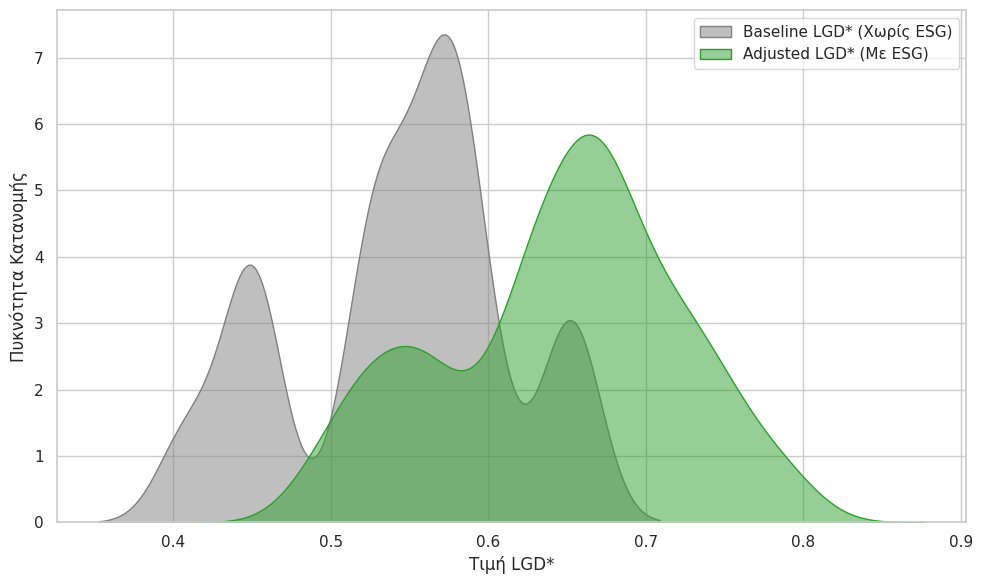

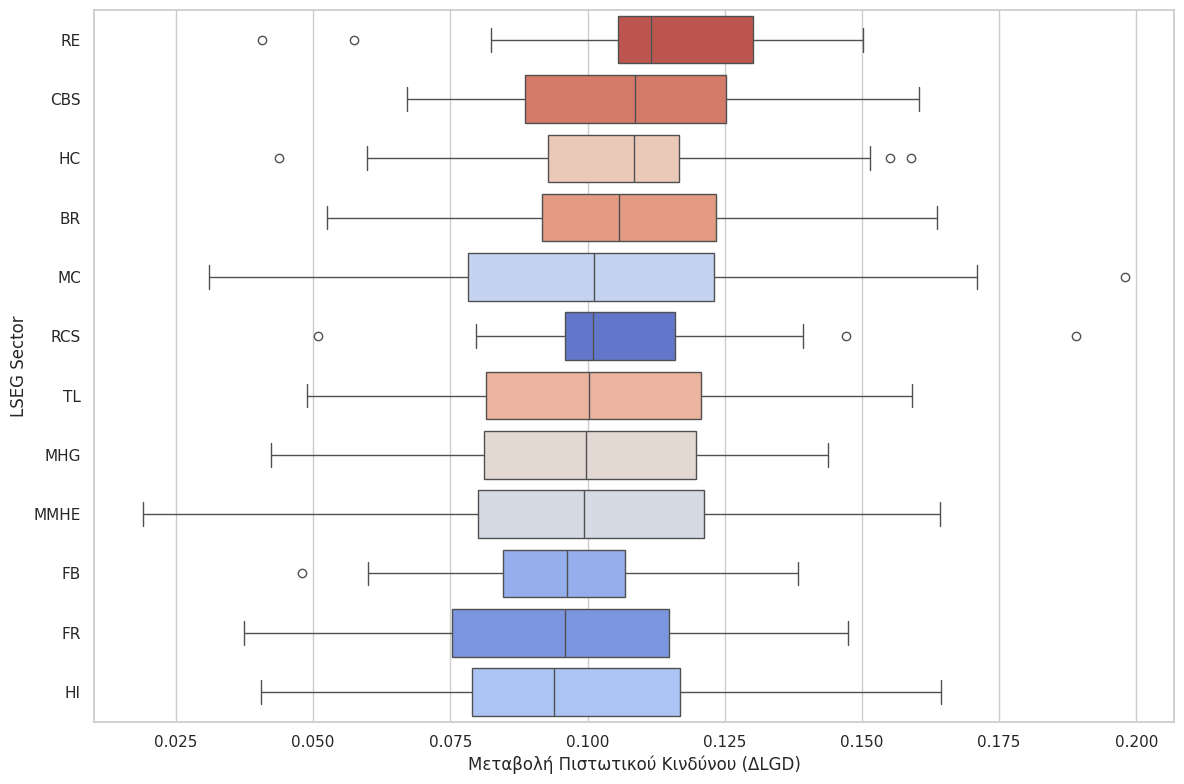

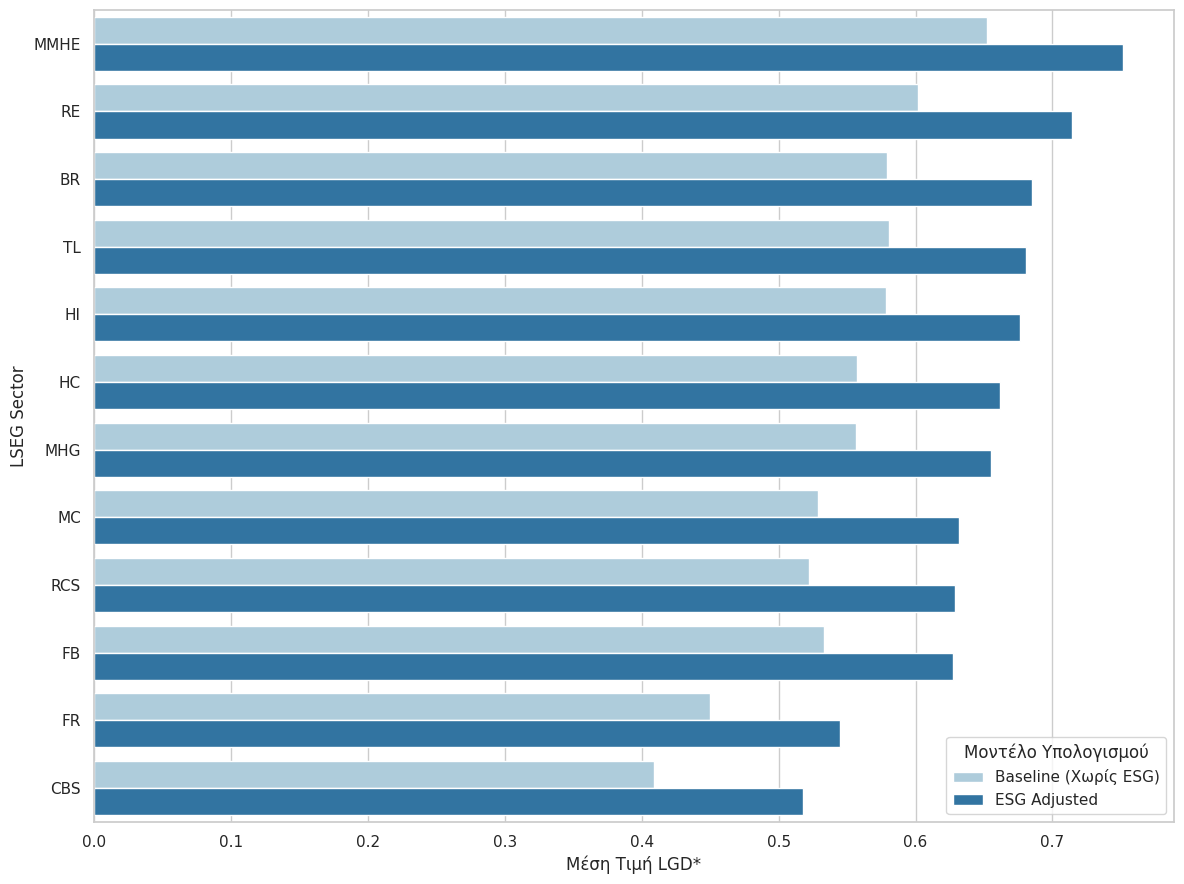

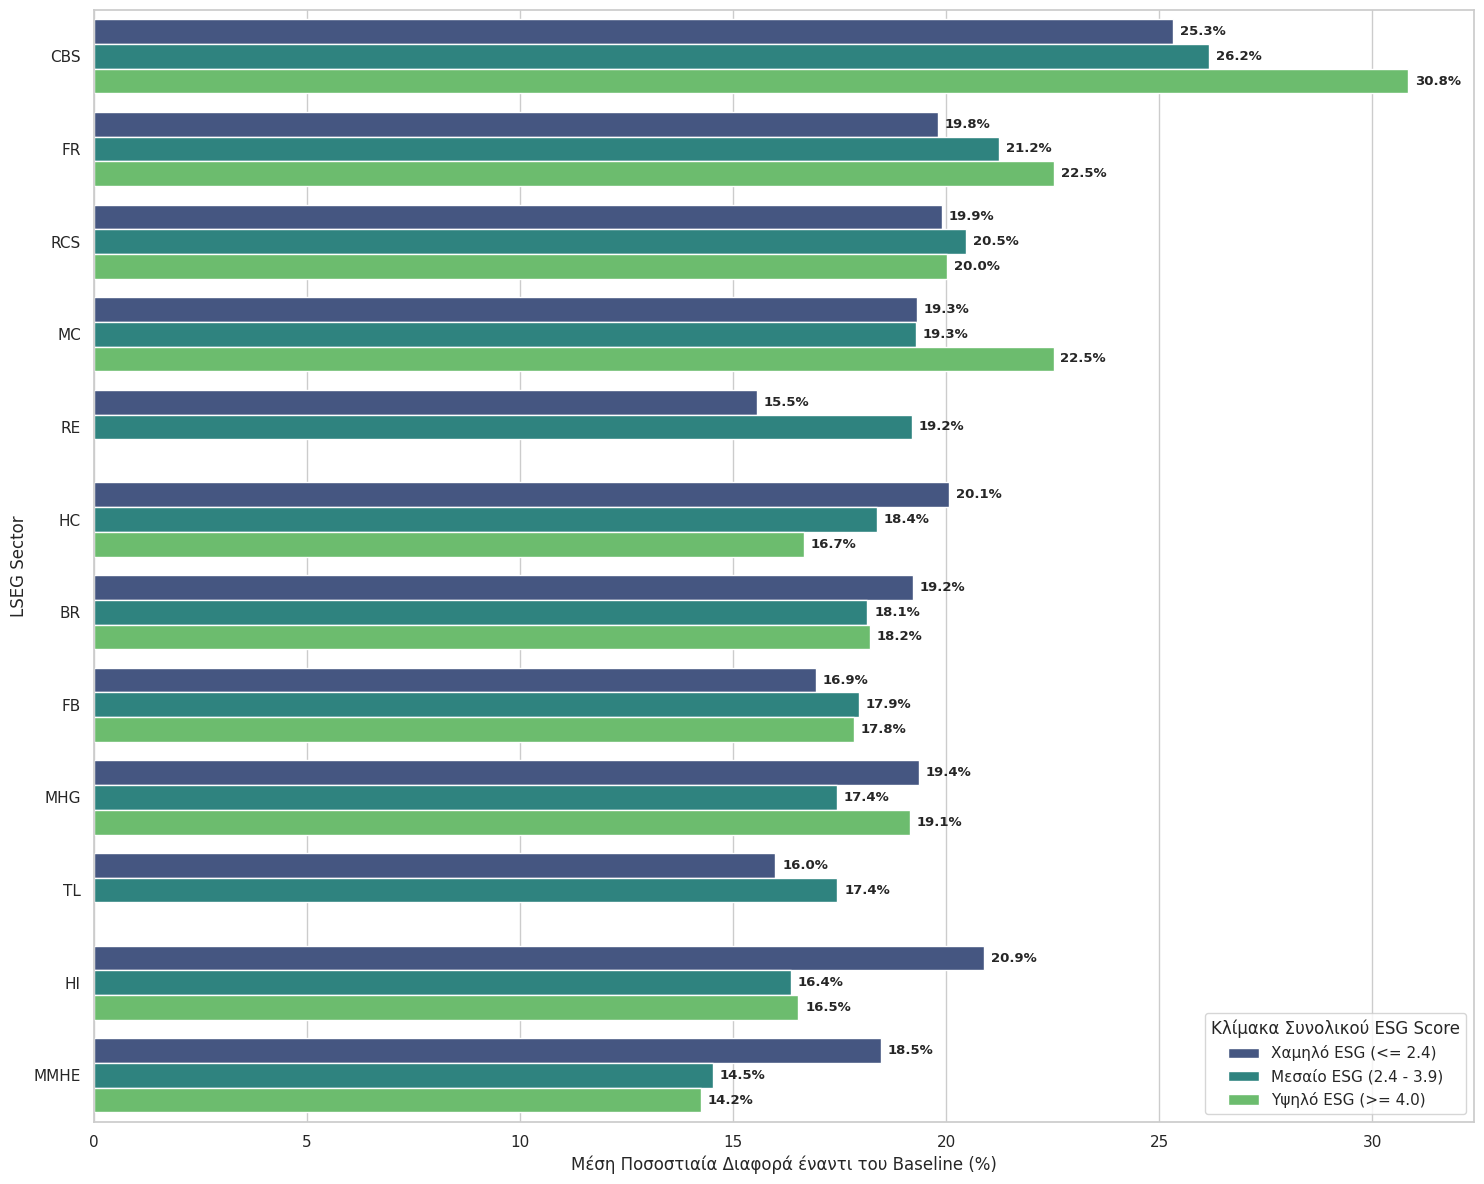

In [4]:
# --------------------------------------------------------------------------------
# LGD with ESG Analysis
# Implementation of the LGD Estimation Model
# --------------------------------------------------------------------------------

# --------------------------------------------------------------------------------
# 1. IMPORT LIBRARIES
# --------------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)

# --------------------------------------------------------------------------------
# 2. LOAD DATA FROM EXCEL
# --------------------------------------------------------------------------------
print("-" * 80)
print("1. ΦΟΡΤΩΣΗ ΔΕΔΟΜΕΝΩΝ ΑΠΟ ΤΟ EXCEL")
print("-" * 80)

# Φόρτωση EXCEL από το dropbox μου
dropbox_link = "https://www.dropbox.com/scl/fi/at55pu7rvud7cag1j5c7a/ALL.xlsx?rlkey=im3rfv21rdcidlcwo9vj143h4&st=8sgnpq3l&dl=0"
download_url = dropbox_link.replace("dl=0", "dl=1")
sheet_names = ['ATHEX25', 'STOXX600', 'S&P500', 'EUROSTOXX50']

print("✓ Οι σύνδεσμοι και οι δείκτες αρχικοποιήθηκαν επιτυχώς.")

# --------------------------------------------------------------------------------
# 3. DATA PREPROCESSING
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("2. ΠΡΟΕΠΕΞΕΡΓΑΣΙΑ ΔΕΔΟΜΕΝΩΝ")
print("-" * 80)

# Ορισμός Collaterals Βαρών των Κλάδων
weights_data = {
    'LSEG Sector': [
        'Basic Resources', 'Heavy Industry', 'Manufacturing Machinery & Heavy Equipment',
        'Manufacturing Household Goods', 'Food & Beverage', 'Transport & Logistics',
        'Healthcare', 'Retail & Consumer Services', 'Consulting & Business Services',
        'Media & Communication', 'Financial Services', 'Real Estate'
    ],
    'w_RE': [0.25, 0.20, 0.20, 0.35, 0.40, 0.30, 0.40, 0.50, 0.15, 0.20, 0.10, 0.90],
    'w_Eq': [0.65, 0.70, 0.75, 0.45, 0.30, 0.60, 0.40, 0.15, 0.10, 0.50, 0.05, 0.05],
    'w_St': [0.10, 0.10, 0.10, 0.20, 0.30, 0.10, 0.20, 0.35, 0.75, 0.30, 0.85, 0.05]
}
df_weights = pd.DataFrame(weights_data)

# Συγκέντρωση Δεδομένων από όλα τα Φύλλα
all_data = []

# Επεξεργασία κάθε Φύλλου
for sheet in sheet_names:
    print(f"Επεξεργασία δείκτη: {sheet}...")

    df = pd.read_excel(download_url, sheet_name=sheet)

    # Καθαρισμός κενών από τους κλάδους
    df['LSEG Sector'] = df['LSEG Sector'].astype(str).str.strip()

    # Δημιουργία στήλης για να ξέρουμε από ποιον δείκτη προήλθε η εταιρεία
    df['Market_Index'] = sheet

    # Ενώνουμε τα δεδομένα της εταιρείας με τα αντίστοιχα βάρη
    df = pd.merge(df, df_weights, on='LSEG Sector', how='left')

    # Υπολογισμός LGD_u
    df['LGD_u'] = np.where(df['LSEG Sector'] == 'Financial Services', 0.45, 0.40)

    # Υπολογισμός M, h_base, c_base, h_ESG, c_ESG
    df['M'] = (((df['w_RE'] + df['w_Eq']) * (5 - df['E_Score'])) +
               (df['w_St'] * ((10 - (df['S_Score'] + df['G_Score'])) / 2))) * 0.2

    df['h_base'] = df['w_RE'] * 0.40 + df['w_Eq'] * 0.45 + df['w_St'] * 0.35
    df['c_base'] = df['w_RE'] * 0.05 + df['w_Eq'] * 0.03 + df['w_St'] * 0.01

    df['h_ESG'] = df['M'] * 0.15
    df['c_ESG'] = df['M'] * 0.02

    # ----------------------------------------------------------------------------
    # ΣΕΝΑΡΙΟ Α: LGD ΜΕ ESG
    # ----------------------------------------------------------------------------
    conditions = [
        df['ESG_Score'] <= 2.4,
        (df['ESG_Score'] > 2.4) & (df['ESG_Score'] <= 3.9),
        df['ESG_Score'] >= 4.0
    ]

    ltv_re = np.select(conditions, [0.65, 0.70, 0.75], default=np.nan)
    ltv_eq = np.select(conditions, [0.60, 0.65, 0.70], default=np.nan)
    ltv_st = np.select(conditions, [0.55, 0.60, 0.65], default=np.nan)

    df['LTV'] = (df['w_RE'] * ltv_re) + (df['w_Eq'] * ltv_eq) + (df['w_St'] * ltv_st)

    df['LGD_s'] = 1 - ((1 - df['h_base'] - df['h_ESG'] - df['c_base'] - df['c_ESG']) / df['LTV'])
    df['LGD_s'] = df['LGD_s'].clip(lower=0)
    df['LGD*'] = df['LGD_u'] + df['LGD_s']

    # ----------------------------------------------------------------------------
    # ΣΕΝΑΡΙΟ Β: BASELINE LGD ΧΩΡΙΣ ESG
    # ----------------------------------------------------------------------------
    df['LTV_No_ESG'] = (df['w_RE'] * 0.70) + (df['w_Eq'] * 0.65) + (df['w_St'] * 0.60)

    df['LGD_s_No_ESG'] = 1 - ((1 - df['h_base'] - df['c_base']) / df['LTV_No_ESG'])
    df['LGD_s_No_ESG'] = df['LGD_s_No_ESG'].clip(lower=0)

    df['LGD*_No_ESG'] = df['LGD_u'] + df['LGD_s_No_ESG']

    # ----------------------------------------------------------------------------
    # Υπολογισμός του ESG Delta
    # ----------------------------------------------------------------------------
    df['Delta_LGD'] = df['LGD*'] - df['LGD*_No_ESG']

    # Καθαρισμός προσωρινών στηλών
    cols_to_drop = ['w_RE', 'w_Eq', 'w_St', 'M', 'LGD_s', 'LGD_s_No_ESG']
    df = df.drop(columns=cols_to_drop)

    all_data.append(df)

# Ενοποίηση
df_final = pd.concat(all_data, ignore_index=True)

# --------------------------------------------------------------------------------
# Κατηγοριοποίηση & Υπολογισμός Ποσοστιαίας Μεταβολής
# --------------------------------------------------------------------------------
conditions_final = [
    df_final['ESG_Score'] <= 2.4,
    (df_final['ESG_Score'] > 2.4) & (df_final['ESG_Score'] <= 3.9),
    df_final['ESG_Score'] >= 4.0
]
esg_categories = ['Χαμηλό ESG (<= 2.4)', 'Μεσαίο ESG (2.4 - 3.9)', 'Υψηλό ESG (>= 4.0)']
df_final['ESG_Scale'] = np.select(conditions_final, esg_categories, default='Unknown')

# Υπολογισμός της ποσοστιαίας διαφοράς
df_final['Pct_Delta_LGD'] = ((df_final['LGD*'] - df_final['LGD*_No_ESG']) / df_final['LGD*_No_ESG']) * 100

# --------------------------------------------------------------------------------
# Αντιστοίχιση Κλάδων σε Αρχικά (Short Codes) για τα Γραφήματα
# --------------------------------------------------------------------------------
sector_mapping = {
    'Financial Services': 'FR',
    'Manufacturing Household Goods': 'MHG',
    'Transport & Logistics': 'TL',
    'Basic Resources': 'BR',
    'Heavy Industry': 'HI',
    'Manufacturing Machinery & Heavy Equipment': 'MMHE',
    'Food & Beverage': 'FB',
    'Healthcare': 'HC',
    'Retail & Consumer Services': 'RCS',
    'Consulting & Business Services': 'CBS',
    'Media & Communication': 'MC',
    'Real Estate': 'RE'
}
# Αντικατάσταση των ονομάτων με τα αρχικά τους στο df_final
df_final['LSEG Sector'] = df_final['LSEG Sector'].map(sector_mapping)

print(f"\n✓ Η επεξεργασία ολοκληρώθηκε επιτυχώς στη μνήμη!")

# --------------------------------------------------------------------------------
# 4. Παραγωγή Γραφικών Παραστάσεων
# --------------------------------------------------------------------------------
print("\n\n" + "-" * 80)
print("3. ΠΑΡΑΓΩΓΗ ΓΡΑΦΗΜΑΤΩΝ")
print("-" * 80)

# Συνολικό Διάγραμμα Επικάλυψης Κατανομών
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_final, x='LGD*_No_ESG', fill=True, color='#808080', label='Baseline LGD* (Χωρίς ESG)', alpha=0.5)
sns.kdeplot(data=df_final, x='LGD*', fill=True, color='#2ca02c', label='Adjusted LGD* (Με ESG)', alpha=0.5)
plt.xlabel('Τιμή LGD*', fontsize=12)
plt.ylabel('Πυκνότητα Κατανομής', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


# Θηκόγραμμα της Διαφοράς (ΔLGD) ανά Κλάδο (Με Αρχικά)
plt.figure(figsize=(12, 8))
sector_order_boxplot = df_final.groupby('LSEG Sector')['Delta_LGD'].median().sort_values(ascending=False).index
sns.boxplot(data=df_final, x='Delta_LGD', y='LSEG Sector', order=sector_order_boxplot, hue='LSEG Sector', legend=False, palette='coolwarm')
plt.xlabel('Μεταβολή Πιστωτικού Κινδύνου (ΔLGD)', fontsize=12)
plt.ylabel('LSEG Sector', fontsize=12)
plt.tight_layout()
plt.show()


# Ομαδοποιημένο Οριζόντιο Ραβδόγραμμα Μέσου LGD ανά Κλάδο (Με Αρχικά)
df_melted = df_final.melt(id_vars=['LSEG Sector'], value_vars=['LGD*_No_ESG', 'LGD*'],
                          var_name='Μοντέλο', value_name='LGD_Value')
df_melted['Μοντέλο'] = df_melted['Μοντέλο'].map({'LGD*_No_ESG': 'Baseline (Χωρίς ESG)', 'LGD*': 'ESG Adjusted'})

plt.figure(figsize=(12, 9))
sector_order_bars = df_final.groupby('LSEG Sector')['LGD*'].mean().sort_values(ascending=False).index
sns.barplot(
    data=df_melted,
    y='LSEG Sector',
    x='LGD_Value',
    hue='Μοντέλο',
    order=sector_order_bars,
    errorbar=None,
    palette={'Baseline (Χωρίς ESG)': '#a6cee3', 'ESG Adjusted': '#1f78b4'}
)
plt.xlabel('Μέση Τιμή LGD*', fontsize=12)
plt.ylabel('LSEG Sector', fontsize=12)
plt.legend(title='Μοντέλο Υπολογισμού', fontsize=11, loc='lower right')
plt.tight_layout()
plt.show()


# Κλάδος x ESG Κλίμακα (Με Αρχικά)
plt.figure(figsize=(15, 12))
sector_order_pct = df_final.groupby('LSEG Sector')['Pct_Delta_LGD'].mean().sort_values(ascending=False).index

ax = sns.barplot(
    data=df_final,
    y='LSEG Sector',
    x='Pct_Delta_LGD',
    hue='ESG_Scale',
    hue_order=esg_categories,
    order=sector_order_pct,
    errorbar=None,
    palette='viridis'
)

plt.xlabel('Μέση Ποσοστιαία Διαφορά έναντι του Baseline (%)', fontsize=12)
plt.ylabel('LSEG Sector', fontsize=12)
plt.legend(title='Κλίμακα Συνολικού ESG Score', fontsize=11, loc='lower right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=5, weight='bold', fontsize=9.5)

plt.tight_layout()
plt.show()